# Lanzar simulaciones RRAM

Notebook adaptado a la **arquitectura init → exec → plot**.

Cada fase es independiente:
- **init**: pre-genera `Init_data/init_state_*.npz` para todas las sims del CSV.
- **exec**: ejecuta el ciclo SET → RESET de una simulación. Persiste `Data_*.npz` + `sim_metadata.json` en `Results/Simulation_{N}/`.
- **plot**: lee del disco y genera figuras. **No** re-ejecuta exec.

Lanzamiento via subcomando `python -m RRAM <init|exec|plot|all>`.

Logging: nivel global por env var `RRAM_LOG_LEVEL=DEBUG|INFO|WARNING`. Cada subprocess escribe `logs/log_simulacion_{N}.log`.

In [1]:
%load_ext autoreload
%autoreload 2

import concurrent.futures
import os
import shutil
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from RRAM import simulation_config

ruta_raiz = Path.cwd()
print('Ruta raiz del proyecto:', ruta_raiz)

Ruta raiz del proyecto: /Users/antonio_lopez_torres/Documents/GitHub/RRAM_Simulation


## 1. Estructura de carpetas

In [2]:
def setup_project_structure():
    """Crea todas las carpetas necesarias antes de ejecutar las simulaciones."""
    folders = [
        'Init_data',
        'Datos_Experimentales/Ciclos_Experimentales',
        'Results',
        'Results/Figures',
        'logs',
    ]
    for folder in folders:
        Path(folder).mkdir(parents=True, exist_ok=True)
        print(f'OK carpeta: {folder}/')

    exp_files = [
        'Datos_Experimentales/Ciclos_Experimentales/Cycle_p_1000.txt',
        'Datos_Experimentales/Ciclos_Experimentales/Cycle_n_1000.txt',
    ]
    print('\nArchivos que DEBES proporcionar manualmente:')
    for f in exp_files:
        marker = 'OK' if os.path.exists(f) else 'FALTA'
        print(f'  [{marker}] {f}')


setup_project_structure()

OK carpeta: Init_data/
OK carpeta: Datos_Experimentales/Ciclos_Experimentales/
OK carpeta: Results/
OK carpeta: Results/Figures/
OK carpeta: logs/

Archivos que DEBES proporcionar manualmente:
  [OK] Datos_Experimentales/Ciclos_Experimentales/Cycle_p_1000.txt
  [OK] Datos_Experimentales/Ciclos_Experimentales/Cycle_n_1000.txt


In [3]:
def safe_reset_folder(folder_path: Path | str) -> None:
    """Borra y recrea una carpeta, evitando rutas peligrosas."""
    folder_path = str(folder_path)
    proteccion = ['c:/users/usuario', 'c:\\users\\usuario', 'c:/users', 'c:\\users', '/']
    if folder_path.strip().lower() in proteccion:
        print(f'ADVERTENCIA: carpeta protegida, no se borra: {folder_path}')
        return
    try:
        if os.path.exists(folder_path):
            shutil.rmtree(folder_path)
        os.makedirs(folder_path)
    except Exception as e:
        print(f'Error al resetear {folder_path}: {e}')


# Limpiar resultados previos
carpeta_results = ruta_raiz / 'Results'
if carpeta_results.exists():
    shutil.rmtree(carpeta_results)
carpeta_results.mkdir(parents=True, exist_ok=True)
(carpeta_results / 'Figures').mkdir(parents=True, exist_ok=True)

# Limpiar logs previos
log_dir = ruta_raiz / 'logs'
log_dir.mkdir(exist_ok=True)
for f in log_dir.iterdir():
    if f.is_file():
        try:
            f.unlink()
        except Exception as e:
            print(f'No se pudo eliminar {f}: {e}')

print('Estructura limpia.')

Estructura limpia.


## 2. Generación de parámetros (CSV → Init_data)

Construye `simulation_parameters.csv` y `simulation_constants.csv` mediante el barrido de parámetros.

In [4]:
manager = simulation_config.ConfigManager()
carpeta_init = 'Init_data'

# Bases de Montecarlo (replicar la fuerza bruta original)
factors_set = [1]
factors_reset = [1]
E_a_base = 1.09
E_r_base = 1.55

# Diccionario de barrido (Grid Search)
parametros_barrido = {
    'device_size_y': [10e-9],
    'ohm_resistence_set': [4.1],
    'ohm_resistence_reset': [4.1]*14,
    'grosor_filamento': [[0, 1], [1, 0]],
    'generation_energy': [round(E_a_base * f, 3) for f in factors_set],
    'recombination_energy': [round(E_r_base * f, 3) for f in factors_reset],
}

manager.add_sweep(sweep_params=parametros_barrido)
manager.export_to_init_data(carpeta_init)

num_simulaciones = len(manager.simulations)
print(f'\nGeneradas {num_simulaciones} configuraciones en {carpeta_init}/.')


Generadas 28 configuraciones en Init_data/.


## 3. INIT — pre-generar estados iniciales

Equivale al antiguo `Init_simulation.py`. Lee el CSV recién creado y deja `Init_data/init_state_{i}.npz` para cada simulación.

In [5]:
resultado = subprocess.run(
    [sys.executable, '-m', 'RRAM', 'init'],
    cwd=str(ruta_raiz),
    capture_output=True, text=True,
)
print(resultado.stdout)
if resultado.returncode != 0:
    print('STDERR:', resultado.stderr)
    raise RuntimeError('init falló')

## 4. EXEC — lanzamiento paralelo del ciclo SET → RESET

Cada simulación es un subprocess `python -m RRAM exec <num>`. La salida ya **no** se redirige: `setup_logging(num+1)` dentro del subprocess escribe directamente `logs/log_simulacion_{N+1}.log`.

Variables de control:
- `RRAM_LOG_LEVEL` por env var (`DEBUG`/`INFO`/`WARNING`).
- `--num-filamentos N` se pasa al CLI.

In [6]:
# Configuración de ejecución
guardar_datos = False
num_filamentos = 2
log_level = os.environ.get('RRAM_LOG_LEVEL', 'INFO')   # cambia a 'DEBUG' para trazar variables
num_procesadores = max(int(0.2 * (os.cpu_count() or 10)), 1)

print(f'Lanzando {num_simulaciones} simulaciones con {num_procesadores} CF. RRAM_LOG_LEVEL={log_level}')


def ejecutar_simulacion(num_simulacion: int) -> int:
    env = os.environ.copy()
    env['RRAM_LOG_LEVEL'] = log_level

    cmd = [
        sys.executable, '-m', 'RRAM', 'exec',
        str(num_simulacion),
        '--num-filamentos', str(num_filamentos),
    ]
    print(f'  Iniciando exec sim={num_simulacion+1}')
    completed = subprocess.run(cmd, cwd=str(ruta_raiz), env=env)
    if completed.returncode != 0:
        print(f'  AVISO: sim {num_simulacion+1} terminó con código {completed.returncode}')
    return completed.returncode


start_time = time.time()
with concurrent.futures.ThreadPoolExecutor(max_workers=num_procesadores) as executor:
    list(executor.map(ejecutar_simulacion, range(num_simulaciones)))
elapsed_h = (time.time() - start_time) / 3600

print(f'\nTodas las simulaciones han terminado.')
print(f'Tiempo total: {elapsed_h:.2f} h ({elapsed_h*3600:.1f} s)')

Lanzando 28 simulaciones con 2 CF. RRAM_LOG_LEVEL=INFO
  Iniciando exec sim=1
  Iniciando exec sim=2
  Iniciando exec sim=3
  Iniciando exec sim=4
  Iniciando exec sim=5
  Iniciando exec sim=6
  AVISO: sim 5 terminó con código 1
  Iniciando exec sim=7
  AVISO: sim 6 terminó con código 1
  Iniciando exec sim=8
  Iniciando exec sim=9
  Iniciando exec sim=10
  AVISO: sim 9 terminó con código 1
  Iniciando exec sim=11
  AVISO: sim 10 terminó con código 1
  Iniciando exec sim=12
  AVISO: sim 12 terminó con código 1
  Iniciando exec sim=13
  Iniciando exec sim=14
  AVISO: sim 14 terminó con código 1
  Iniciando exec sim=15
  Iniciando exec sim=16
  Iniciando exec sim=17
  Iniciando exec sim=18
  AVISO: sim 18 terminó con código 1
  Iniciando exec sim=19
  Iniciando exec sim=20
  AVISO: sim 20 terminó con código 1
  Iniciando exec sim=21
  Iniciando exec sim=22
  AVISO: sim 21 terminó con código 1
  Iniciando exec sim=23
  Iniciando exec sim=24
  Iniciando exec sim=25
  AVISO: sim 24 terminó 

## 5. PLOT — generar figuras leyendo del disco (NO re-ejecuta)

Independiente de la celda anterior. Funciona también en una sesión nueva donde solo tengas las carpetas `Results/Simulation_{N}/`.

In [7]:
# Plot vía CLI (subprocess paralelo opcional)
def plotear_simulacion(num_simulacion: int) -> int:
    # `exec` guarda en Simulation_{num+1}/, así que `plot` recibe num+1.
    n_save = num_simulacion + 1
    cmd = [sys.executable, '-m', 'RRAM', 'plot', str(n_save)]
    completed = subprocess.run(cmd, cwd=str(ruta_raiz))
    if completed.returncode != 0:
        print(f'  Plot falló para sim {n_save}')
    return completed.returncode


for n in range(num_simulaciones):
    plotear_simulacion(n)

print('\nFiguras generadas.')


Figuras generadas.


### Plot programático (sin subprocess)

Útil cuando quieres replotear **sin** salir del notebook ni re-ejecutar el ciclo:

In [8]:
from RRAM.plot_results import plot_results
from RRAM.logging_config import setup_logging

# Replot sin subprocess (más rápido para iterar sobre estilos de gráfico)
setup_logging(num_simulation=None, to_console=True)   # log a stderr en el notebook

for n in range(num_simulaciones):
    plot_results(num_simulation=n + 1)

16:46:30 [INFO   ] RRAM.plot_results: Replot · sim=1 · status=completed · V_perco=0.6420V · creaciones=2 · roturas=2
16:46:30 [INFO   ] RRAM.iv_analysis: Puntos en la curva I-V:
16:46:30 [INFO   ] RRAM.iv_analysis:   Punto a: V = 0.000000 V, I = 0.000000e+00 A
16:46:30 [INFO   ] RRAM.iv_analysis:   Punto b: V = 0.641960 V, I = 4.473589e-03 A
16:46:30 [INFO   ] RRAM.iv_analysis:   Punto c: V = 1.100000 V, I = 2.997084e-02 A
16:46:30 [INFO   ] RRAM.iv_analysis:   Punto d: V = -0.440000 V, I = 1.199128e-02 A
16:46:30 [INFO   ] RRAM.iv_analysis:   Punto e: V = -1.139320 V, I = 7.939512e-03 A
16:46:30 [INFO   ] RRAM.iv_analysis:   Punto f: V = -1.100000 V, I = 2.997629e-02 A
16:46:30 [INFO   ] RRAM.iv_analysis:   Punto g: V = -0.000000 V, I = 1.845236e-07 A


16:46:31 [INFO   ] RRAM.plot_results: Replot · sim=2 · status=completed · V_perco=0.6249V · creaciones=2 · roturas=2
16:46:31 [INFO   ] RRAM.iv_analysis: Puntos en la curva I-V:
16:46:31 [INFO   ] RRAM.iv_analysis:   Punto a: V = 0.000000 V, I = 0.000000e+00 A
16:46:31 [INFO   ] RRAM.iv_analysis:   Punto b: V = 0.624910 V, I = 4.417886e-03 A
16:46:31 [INFO   ] RRAM.iv_analysis:   Punto c: V = 1.100000 V, I = 2.889469e-02 A
16:46:31 [INFO   ] RRAM.iv_analysis:   Punto d: V = -0.440000 V, I = 1.156071e-02 A
16:46:31 [INFO   ] RRAM.iv_analysis:   Punto e: V = -1.117340 V, I = 6.987742e-03 A
16:46:31 [INFO   ] RRAM.iv_analysis:   Punto f: V = -1.100000 V, I = 2.889994e-02 A
16:46:31 [INFO   ] RRAM.iv_analysis:   Punto g: V = -0.000000 V, I = 1.845236e-07 A
16:46:33 [INFO   ] RRAM.plot_results: Replot · sim=3 · status=completed · V_perco=0.6090V · creaciones=2 · roturas=2
16:46:33 [INFO   ] RRAM.iv_analysis: Puntos en la curva I-V:
16:46:33 [INFO   ] RRAM.iv_analysis:   Punto a: V = 0.00000

## 6. Inspección rápida — curvas I-V conjuntas

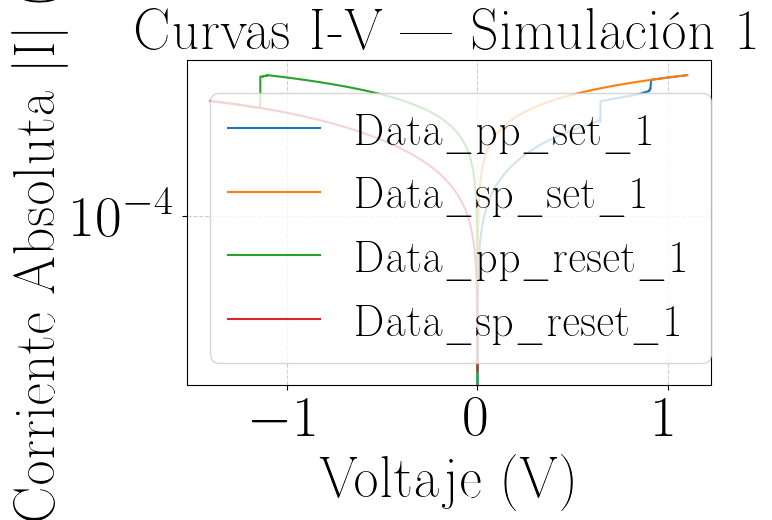

In [9]:
# Plot rápido sumando todas las simulaciones — útil para vista panorámica
num_inspect = 1   # qué simulación inspeccionar (1-indexed, igual que las carpetas)

archivos = [
    f'Results/Simulation_{num_inspect}/Data_pp_set_{num_inspect}.npz',
    f'Results/Simulation_{num_inspect}/Data_sp_set_{num_inspect}.npz',
    f'Results/Simulation_{num_inspect}/Data_pp_reset_{num_inspect}.npz',
    f'Results/Simulation_{num_inspect}/Data_sp_reset_{num_inspect}.npz',
]

plt.figure(figsize=(8, 6))
for archivo in archivos:
    ruta = Path(archivo)
    if not ruta.exists():
        print(f'No encontrado: {archivo}')
        continue
    datos = np.load(ruta)
    matriz = datos['datos_sim']
    voltaje, corriente = matriz[:, 1], matriz[:, 2]
    plt.plot(voltaje, np.abs(corriente), label=ruta.stem)

plt.title(f'Curvas I-V — Simulación {num_inspect}')
plt.xlabel('Voltaje (V)')
plt.ylabel('Corriente Absoluta |I| (A)')
plt.yscale('log')
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig('Grafica_IV_Conjunta.png', dpi=300)
plt.show()

## 7. Inspección de un estado intermedio guardado

Las fases guardan estados cada `num_pasos_guardar_estado` pasos en `Results/Simulation_{N}/<etapa>/`.

In [10]:
from RRAM import Representate

num_simulacion = 2
num_paso = 4000
etapa = 'pp_set'

ruta_npz = Path(
    f'Results/simulation_{num_simulacion}/{etapa.split("_")[1]}/'
    f'Estado_pp_set_sim_{num_simulacion}_paso_{num_paso}.npz'
)

if ruta_npz.exists():
    datos_estado = np.load(ruta_npz)
    matriz_estado = datos_estado['actual_state']
    voltaje_simulacion = num_paso * 0.00011
    ruta_figura = Path.cwd() / f'Estado_{etapa}_sim_{num_simulacion}_paso_{num_paso}.png'
    Representate.RepresentateState(
        matriz=matriz_estado, voltaje=round(voltaje_simulacion, 5), filename=str(ruta_figura)
    )
    print(f'Imagen guardada en {ruta_figura}')
else:
    print(f'No se encontró {ruta_npz}. Ajusta num_simulacion/num_paso/etapa.')

16:46:58 [INFO   ] RRAM.Representate: Dimensiones del dispositivo: 10.00 nm x 10.00 nm


Imagen guardada en /Users/antonio_lopez_torres/Documents/GitHub/RRAM_Simulation/Estado_pp_set_sim_2_paso_4000.png
